# 05. Análisis de Resultados, Robustez y Monte Carlo

En este notebook final consolidamos el rendimiento del algoritmo, lo comparamos con el benchmark (SPY) y sometemos el sistema a pruebas de estrés extremas (Monte Carlo).

### 1. Carga de Resultados y Benchmark

✅ Datos de SPY cargados desde caché local.


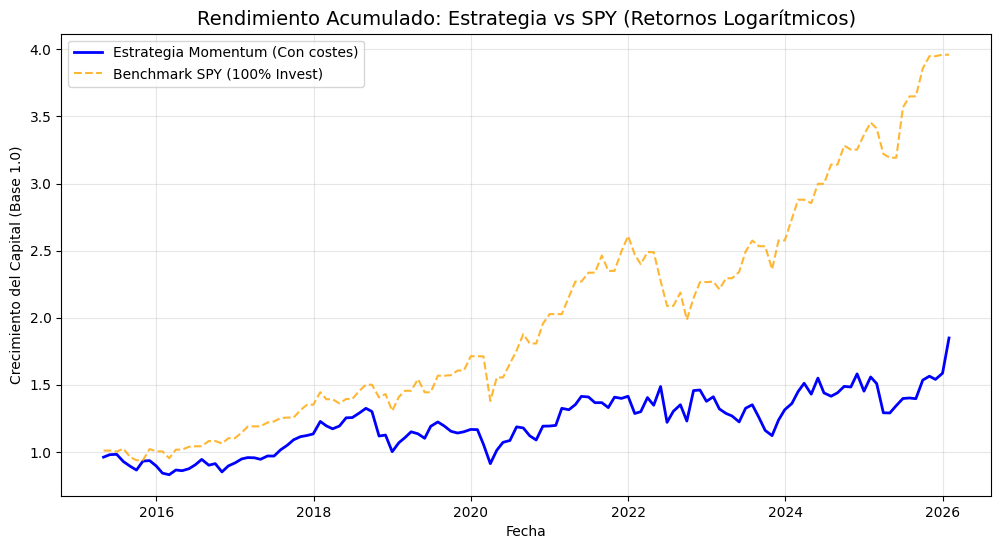

In [1]:
import yfinance as yf
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar los resultados de la estrategia (esto ya lo tienes)
strat_results = pd.read_csv('Datos/backtest_results_with_costs.csv', index_col=0, parse_dates=True)

# --- INICIO DEL BLOQUE DE BENCHMARK (SPY) ---

# Definir fechas del backtest para sincronizar el Benchmark
start_date = strat_results.index.min()
end_date = strat_results.index.max()
cache_path = 'Datos/spy_benchmark.csv'

# Lógica de Caché: Verificar si el archivo existe y si tiene los datos actualizados
download_needed = True
if os.path.exists(cache_path):
    spy_cached = pd.read_csv(cache_path, index_col=0, parse_dates=True)
    # Comprobamos si el caché llega hasta la fecha final de nuestro backtest
    if spy_cached.index.max() >= end_date:
        print("✅ Datos de SPY cargados desde caché local.")
        spy_data = spy_cached
        download_needed = False

if download_needed:
    print(f"🚀 Descargando SPY desde Yahoo Finance ({start_date.date()} a {end_date.date()})...")
    
    # Descarga de datos
    spy_raw = yf.download('SPY', 
                          start=start_date, 
                          end=end_date + pd.Timedelta(days=5), 
                          auto_adjust=True, 
                          progress=False)['Close']
    
    # 1. Realizamos el remuestreo (Monthly End)
    # Nota: Si tu versión de pandas es antigua (<2.2.0), usa 'M' en lugar de 'ME'
    spy_data = spy_raw.resample('ME').last()

    # 2. CORRECCIÓN: Solo convertimos a frame si es una Serie
    if isinstance(spy_data, pd.Series):
        spy_data = spy_data.to_frame()
        
    # 3. Renombramos la columna (ahora estamos seguros de que es un DataFrame)
    spy_data.columns = ['SPY']
    
    # Guardar en caché
    spy_data.to_csv(cache_path)
    print("💾 Datos de SPY guardados en Datos/spy_benchmark.csv")

# Alinear SPY con las fechas exactas que tiene tu estrategia
benchmark_prices = spy_data.reindex(strat_results.index).ffill()

# CÁLCULO DE RETORNOS LOGARÍTMICOS
# Estrategia: ln(Valor_t / Valor_t-1)
strat_log_rets = np.log(strat_results['TotalValue'] / strat_results['TotalValue'].shift(1)).dropna()

# Benchmark (SPY): ln(Precio_t / Precio_t-1)
benchmark_log_rets = np.log(benchmark_prices['SPY'] / benchmark_prices['SPY'].shift(1)).dropna()

# Sincronizar índices para comparar exactamente los mismos meses
common_index = strat_log_rets.index.intersection(benchmark_log_rets.index)
strat_log_rets = strat_log_rets.loc[common_index]
benchmark_log_rets = benchmark_log_rets.loc[common_index]

# GRÁFICA DE COMPARACIÓN (Equity Curve - Escala Lineal reconstruida desde Log)
plt.figure(figsize=(12, 6))
# Usamos exp(cumsum) para convertir los retornos logarítmicos en una curva de capital base 1.0
plt.plot(strat_log_rets.cumsum().apply(np.exp), label='Estrategia Momentum (Con costes)', color='blue', linewidth=2)
plt.plot(benchmark_log_rets.cumsum().apply(np.exp), label='Benchmark SPY (100% Invest)', color='orange', linestyle='--', alpha=0.8)

plt.title('Rendimiento Acumulado: Estrategia vs SPY (Retornos Logarítmicos)', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Crecimiento del Capital (Base 1.0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Actualizar variables para el resto del notebook (cuadro de métricas, etc.)
strat_rets = strat_log_rets
benchmark_rets = benchmark_log_rets


### 2. Cuadro de Métricas Profesionales

In [2]:
def calculate_metrics(returns, benchmark=None):
    cagr = (returns + 1).prod()**(12 / len(returns)) - 1
    vol = returns.std() * np.sqrt(12)
    sharpe = (returns.mean() * 12) / vol
    
    neg_returns = returns[returns < 0]
    sortino = (returns.mean() * 12) / (neg_returns.std() * np.sqrt(12))
    
    cum_rets = (1 + returns).cumprod()
    max_dd = (cum_rets / cum_rets.cummax() - 1).min()
    
    metrics = {
        'CAGR': f"{cagr:.2%}",
        'Volatilidad': f"{vol:.2%}",
        'Sharpe Ratio': f"{sharpe:.2f}",
        'Sortino Ratio': f"{sortino:.2f}",
        'Max Drawdown': f"{max_dd:.2%}"
    }
    
    if benchmark is not None:
        cov = np.cov(returns, benchmark)[0, 1]
        beta = cov / np.var(benchmark)
        alpha = (returns.mean() * 12) - (beta * benchmark.mean() * 12)
        metrics['Beta'] = f"{beta:.2f}"
        metrics['Alpha'] = f"{alpha:.2%}"
        
    return metrics

table = pd.DataFrame({
    'Estrategia Momentum': calculate_metrics(strat_rets, benchmark_rets),
    'Benchmark (SPY)': calculate_metrics(benchmark_rets)
})
table

,Estrategia Momentum,Benchmark (SPY)
CAGR,3.65%,12.09%
Volatilidad,20.29%,15.56%
Sharpe Ratio,0.28,0.82
Sortino Ratio,0.37,0.84
Max Drawdown,-34.21%,-25.20%
Beta,0.75,NaN
Alpha,-3.87%,NaN


## ⚠️ Consideraciones Críticas del Backtesting

1. **Look-ahead bias:** Usar SOLO información disponible en el momento de decisión
2. **Transaction costs:** No modelados (simplificación para MVP)
3. **Slippage:** Asumimos ejecución a precio de cierre (optimista)
4. **Impacto de mercado:** Ignorado (válido para AUM pequeños)
5. **Survivor bias:** Minimizado (megacaps activas todo el periodo)

## 5. Análisis de Recurrencia

El análisis de recurrencia permite evaluar la consistencia del modelo a lo largo de múltiples periodos (mensuales, trimestrales, anuales), determinando qué tan seguido el modelo logra superar al benchmark en diferentes ventanas temporales.

Calculando recurrencia Trimestral...


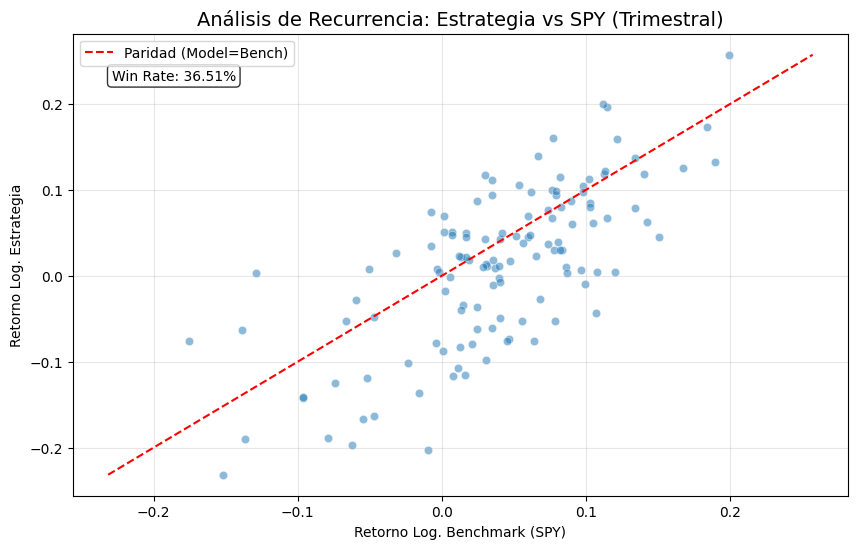

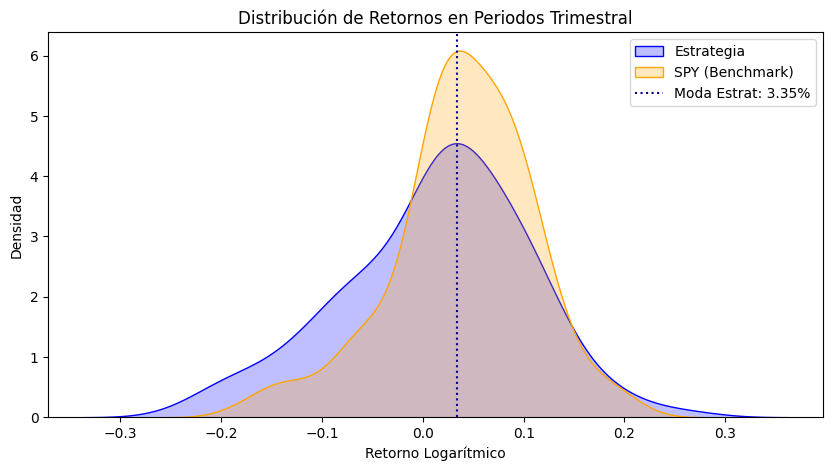

Calculando recurrencia Anual...


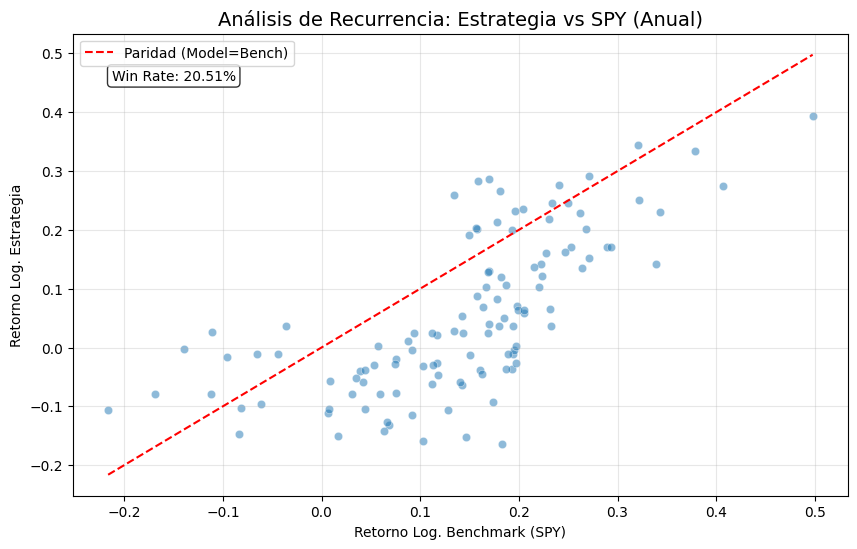

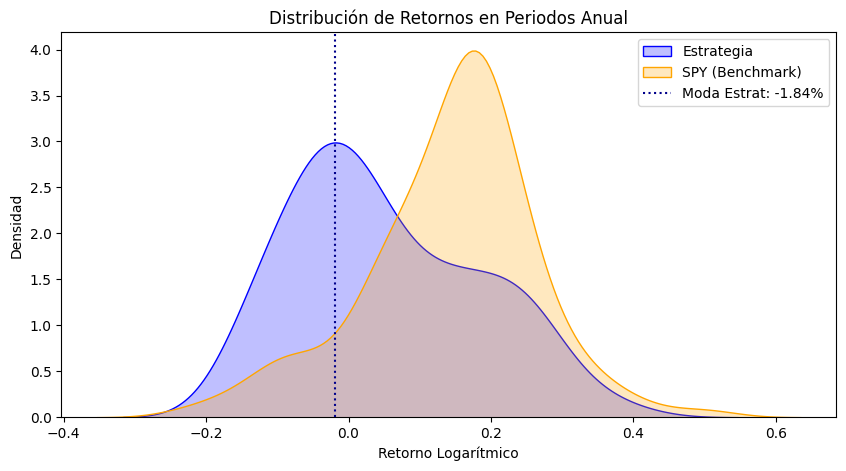

In [3]:
import seaborn as sns
from scipy import stats
from pandas.tseries.offsets import DateOffset

def generate_period_returns(strat_log_ret, bench_log_ret, period_type, random=False, num_periods=1000):
    """
    Calcula los retornos acumulados para ventanas temporales (M, Q, Y, etc.)
    """
    # Definir el desplazamiento temporal
    offsets = {
        'M': DateOffset(months=1),
        'Q': DateOffset(months=3),
        'S': DateOffset(months=6),
        'Y': DateOffset(years=1),
        '2Y': DateOffset(years=2)
    }
    
    if period_type not in offsets:
        raise ValueError("Periodo no reconocido. Usa M, Q, S, Y o 2Y.")
    
    offset = offsets[period_type]
    results = []
    
    # Determinamos los puntos de inicio
    max_date = strat_log_ret.index.max() - offset
    possible_starts = strat_log_ret.loc[:max_date].index
    
    if random:
        # Selección aleatoria de periodos
        starts = np.random.choice(possible_starts, size=num_periods)
    else:
        # Todos los periodos posibles (Rolling)
        starts = possible_starts

    for start in starts:
        end = start + offset
        # Sumamos retornos logarítmicos en el intervalo
        m_ret = strat_log_ret.loc[start:end].sum()
        b_ret = bench_log_ret.loc[start:end].sum()
        
        results.append({
            'start_date': start,
            'end_date': end,
            'model_ret': m_ret,
            'bench_ret': b_ret
        })
        
    return pd.DataFrame(results)

def plot_recurrence_analysis(df_results, period_label):
    """
    Genera los gráficos de comparación y densidad
    """
    # 1. Gráfico de Dispersión
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_results, x='bench_ret', y='model_ret', alpha=0.5)
    
    # Línea de paridad (y=x)
    min_val = min(df_results['bench_ret'].min(), df_results['model_ret'].min())
    max_val = max(df_results['bench_ret'].max(), df_results['model_ret'].max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Paridad (Model=Bench)')
    
    # Estadísticas
    win_rate = (df_results['model_ret'] > df_results['bench_ret']).mean() * 100
    avg_excess = (df_results['model_ret'] - df_results['bench_ret']).mean()
    
    plt.title(f'Análisis de Recurrencia: Estrategia vs SPY ({period_label})', fontsize=14)
    plt.xlabel('Retorno Log. Benchmark (SPY)')
    plt.ylabel('Retorno Log. Estrategia')
    
    plt.annotate(f'Win Rate: {win_rate:.2f}%', 
                 xy=(0.05, 0.9), xycoords='axes fraction', 
                 bbox=dict(boxstyle="round", fc="white", alpha=0.8))
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    # 2. Gráfico de Densidad
    plt.figure(figsize=(10, 5))
    sns.kdeplot(df_results['model_ret'], label='Estrategia', fill=True, color='blue')
    sns.kdeplot(df_results['bench_ret'], label='SPY (Benchmark)', fill=True, color='orange')
    
    # Marcar la moda (KDE) para la estrategia
    kde = stats.gaussian_kde(df_results['model_ret'])
    x_range = np.linspace(df_results['model_ret'].min(), df_results['model_ret'].max(), 1000)
    mode_val = x_range[np.argmax(kde(x_range))]
    plt.axvline(mode_val, color='darkblue', linestyle=':', label=f'Moda Estrat: {mode_val:.2%}')

    plt.title(f'Distribución de Retornos en Periodos {period_label}')
    plt.xlabel('Retorno Logarítmico')
    plt.ylabel('Densidad')
    plt.legend()
    plt.show()

# --- ANÁLISIS TRIMESTRAL (Q) ---
print("Calculando recurrencia Trimestral...")
df_q = generate_period_returns(strat_rets, benchmark_rets, period_type='Q', random=False)
plot_recurrence_analysis(df_q, "Trimestral")

# --- ANÁLISIS ANUAL (Y) ---
print("Calculando recurrencia Anual...")
df_y = generate_period_returns(strat_rets, benchmark_rets, period_type='Y', random=False)
plot_recurrence_analysis(df_y, "Anual")